# fashion-mnist-mlp

MLP model trained on the Fashion MNIST dataset with PyTorch 2.8.0 + CANN 8.5.0 with the architecture below.

1. 1st hidden layer with 784 input channels, 1024 output channels, ReLU activation
1. 1st dropout layer with `p = 0.3`
1. 2nd hidden layer with 1024 input channels, 512 output channels, ReLU activation
1. 2nd dropout layer with `p = 0.2`
1. Fully connected layer with 512 input channels, 10 output channels

## Loading the dataset

In [1]:
import shutil

dataset_src_dir = '/kaggle/input/datasets/organizations/zalando-research/fashionmnist'
dataset_dst_dir = 'FashionMNIST/raw/'
shutil.copytree(dataset_src_dir, dataset_dst_dir, dirs_exist_ok=True)

'FashionMNIST/raw/'

In [2]:
import os
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

test_data = datasets.FashionMNIST(root=os.getcwd(), train=False, transform=transforms.ToTensor())
test_loader = DataLoader(test_data, batch_size=10, shuffle=True)
X_test, y_test = next(iter(test_loader))
X_test, y_test = X_test.numpy(), y_test.numpy()
X_test.shape, y_test.shape

((10, 1, 28, 28), (10,))

## Inferencing

In [3]:
%pip install onnxruntime-gpu==1.25.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 271.3/271.3 MB 5.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [4]:
import onnxruntime as ort

ort.get_available_providers()

['TensorrtExecutionProvider', 'CUDAExecutionProvider', 'CPUExecutionProvider']

In [5]:
model_path = '/kaggle/input/models/donaldsebleung/fashion-mnist-mlp/pytorch/default/1/fashion-mnist-mlp.onnx'
session = ort.InferenceSession(model_path, providers=['CUDAExecutionProvider'])
session.get_providers()

['CUDAExecutionProvider', 'CPUExecutionProvider']

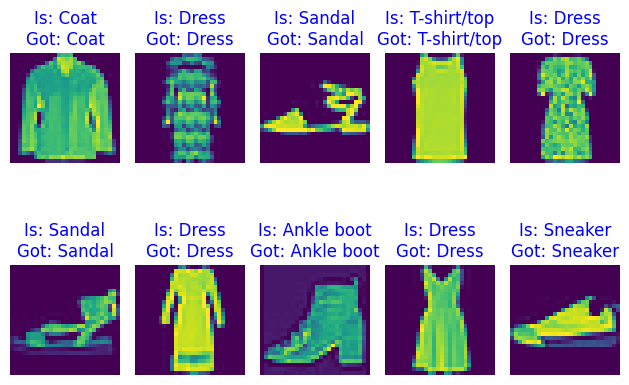

In [6]:
import matplotlib.pyplot as plt
import numpy as np

LABELS = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot'
]
input_name = session.get_inputs()[0].name
fig, axes = plt.subplots(2, 5)
for axis_idx, axis in enumerate(axes.flatten()):
    actual = y_test[axis_idx].item()
    garment = X_test[axis_idx:axis_idx+1]
    predicted = session.run(None, {input_name: garment})[0]
    predicted = np.argmax(predicted, axis=1).item()
    correct = predicted == actual
    color = 'blue' if correct else 'red'
    axis.set_title(f'Is: {LABELS[actual]}\nGot: {LABELS[predicted]}', color=color)
    axis.imshow(np.squeeze(garment, axis=0).transpose(1, 2, 0))
    axis.axis('off')
fig.tight_layout()
fig.show()